# Exploratory Data Analysis (EDA)

## Project: ChurnShield — Customer Churn Prediction

### Objective

The purpose of Exploratory Data Analysis (EDA) is to understand the dataset, identify important customer behavior patterns, and discover the major factors influencing customer churn.

This notebook includes:

- Dataset overview
- Customer churn distribution
- Demographic analysis
- Contract analysis
- Monthly charges analysis
- Customer tenure analysis
- Correlation analysis
- Business insights

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(8,5)

In [4]:
df=pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.shape

(7043, 21)

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Customer Churn Distribution

/tmp/ipykernel_429/2253350044.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn',data=df,palette='Set2')


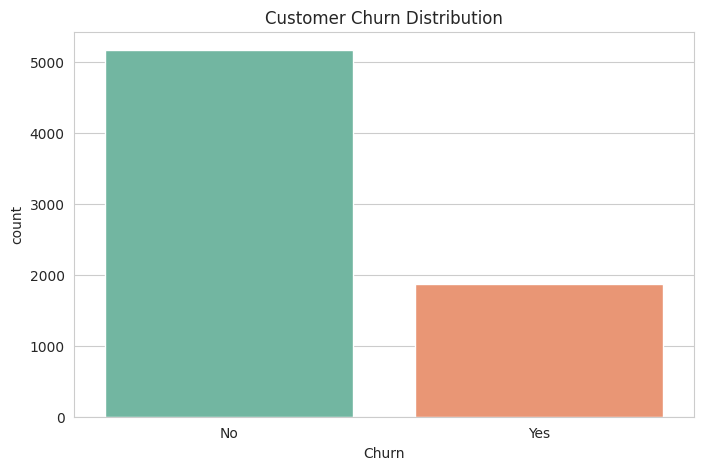

In [8]:
sns.countplot(x='Churn',data=df,palette='Set2')
plt.title("Customer Churn Distribution")
plt.show()

### Observation

The distribution shows the proportion of customers who stayed and customers who churned.

Understanding class distribution is important before building predictive models.

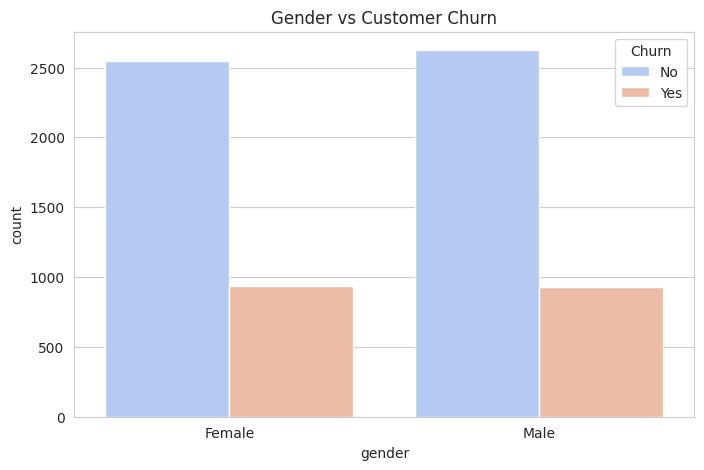

In [9]:
sns.countplot(x='gender',hue='Churn',data=df,palette='coolwarm')
plt.title("Gender vs Customer Churn")
plt.show()

### Observation

Customer churn appears relatively balanced across genders.

Gender alone may not be a strong predictor of churn.

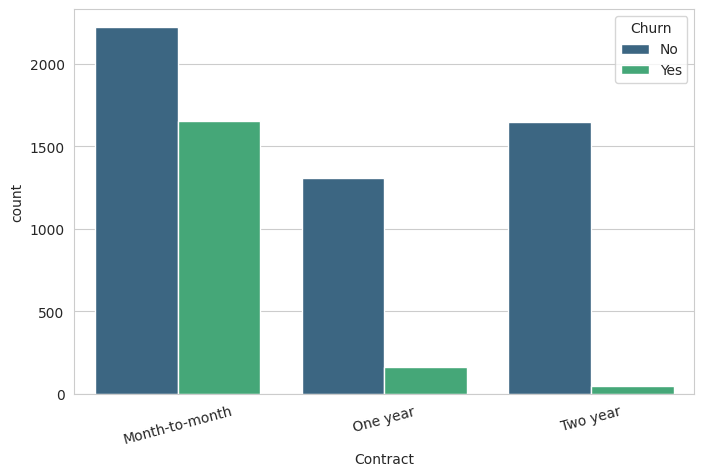

In [10]:
sns.countplot(x='Contract',hue='Churn',data=df,palette='viridis')
plt.xticks(rotation=15)
plt.show()

### Observation

Customers with Month-to-Month contracts experience significantly higher churn compared to One Year and Two Year contracts.

/tmp/ipykernel_429/3720732222.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn',y='MonthlyCharges',data=df,palette='Set3')


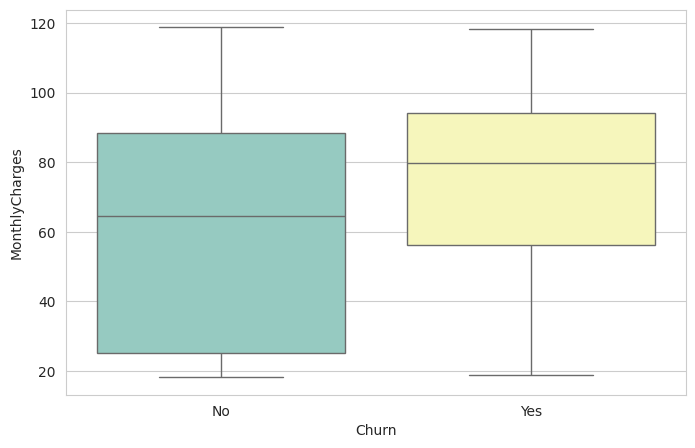

In [11]:
sns.boxplot(x='Churn',y='MonthlyCharges',data=df,palette='Set3')
plt.show()

### Observation

Customers paying higher monthly charges tend to have higher churn rates.

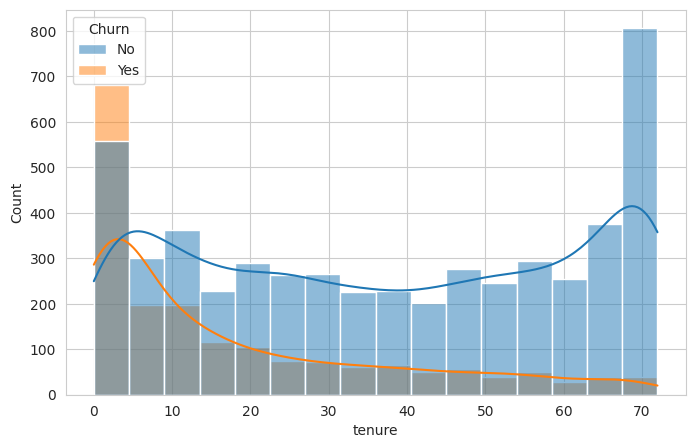

In [18]:
sns.histplot(data=df,
             x='tenure',
             hue='Churn',
             kde=True)

plt.show()

### Observation

Customers with lower tenure tend to churn more frequently than long-term customers.

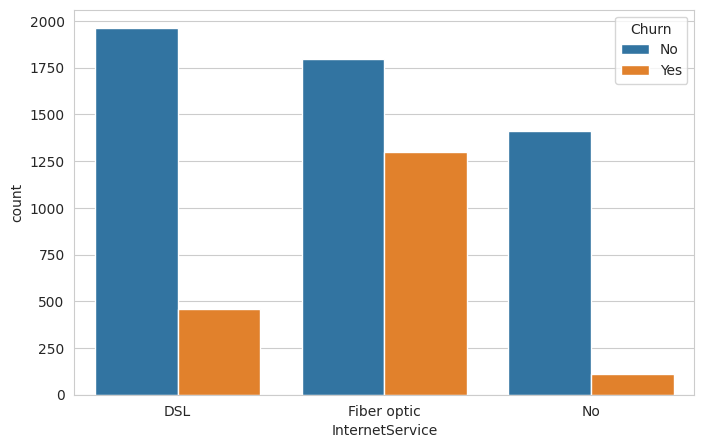

In [14]:
sns.countplot(x='InternetService',
              hue='Churn',
              data=df)

plt.show()

### Observation

Internet service type influences customer churn and should be considered during feature selection.

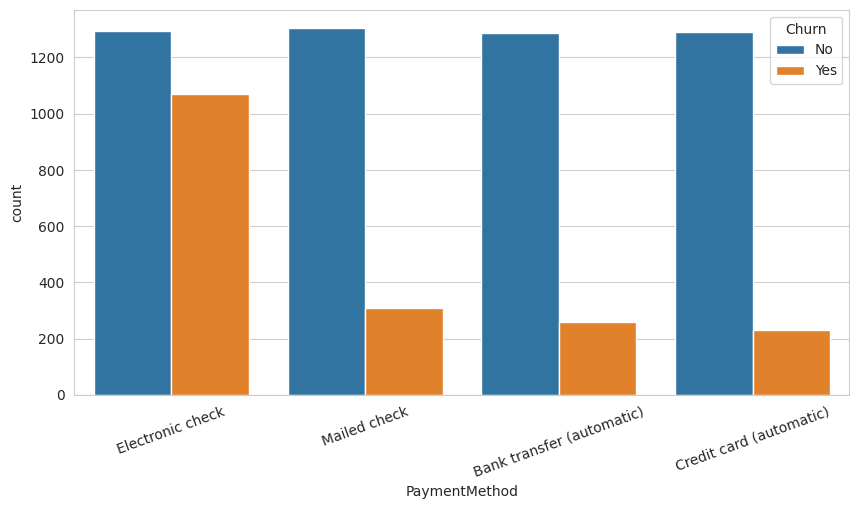

In [13]:
plt.figure(figsize=(10,5))

sns.countplot(x='PaymentMethod',
              hue='Churn',
              data=df)

plt.xticks(rotation=20)

plt.show()

### Observation

Certain payment methods appear to have relatively higher churn percentages than others.

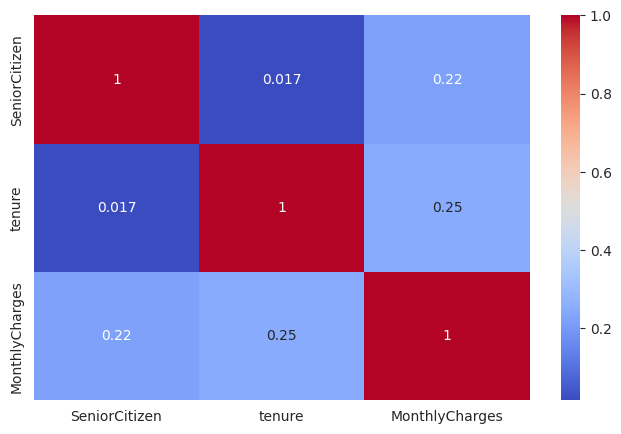

In [12]:
numeric=df.select_dtypes(include=['number'])

sns.heatmap(numeric.corr(),
            annot=True,
            cmap='coolwarm')

plt.show()

### Observation

The correlation matrix highlights relationships among numerical variables and helps identify useful features for model training.

# Business Insights

The exploratory analysis suggests that customer churn is influenced by multiple business factors.

### Key Findings

- Month-to-Month contracts show the highest churn.
- Customers with shorter tenure are more likely to leave.
- Higher monthly charges may increase churn probability.
- Internet service and payment method also contribute to customer behavior.

These insights will be utilized in the Machine Learning notebook to build predictive models capable of identifying high-risk customers.